# 🚛 Estimativa de Ocupação e Classificação de Carga (Cheio vs. Vazio)
## Abordagem Geométrica Baseada em Segmentação por Instância (YOLOv11 & PyTorch)
> **Branch**: `feature/classificacao-binaria`  
> **Disciplina**: Engenharia de Software para IA e Frameworks Profundos - Especialização em Deep Learning (UFPE)

---

### 🎯 Objetivo desta Feature
Transformar as máscaras geradas pelo modelo **YOLOv11-seg** (`best.pt`) em uma métrica de negócio direta: **classificar caminhões em Vazio, Parcialmente Cheio ou Cheio**, calculando a **Taxa de Ocupação da Caçamba**:

$$\text{Taxa de Ocupação (\%)} = \frac{\text{Área de Pixels da Máscara de Carvão } (\texttt{coal})}{\text{Área de Pixels da Máscara da Caçamba } (\texttt{bed})} \times 100$$

### 📋 Regras de Classificação (Thresholds Operacionais):
* 🟢 **Vazio (`Empty`)**: Sem carvão detectado (`area_coal == 0`) ou $\text{Taxa de Ocupação} < 10\%$
* 🟡 **Parcialmente Cheio (`Partially Loaded`)**: $10\% \le \text{Taxa de Ocupação} < 50\%$
* 🔴 **Cheio (`Full`)**: $\text{Taxa de Ocupação} \ge 50\%$ ou carvão predominante na caçamba

> **Aviso**: Execute a célula abaixo **apenas se estiver executando este notebook no Google Colab**. No ambiente local gerenciado pelo `uv` (`pyproject.toml`), todas as dependências já estão instaladas.

In [1]:
# =============================================================================
# Instalação Automática de Dependências no Google Colab
# =============================================================================
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    print("🚀 Detectado Google Colab. Instalando ultralytics e dependências...")
    get_ipython().system("pip install -q ultralytics roboflow seaborn")
    print("✅ Dependências instaladas com sucesso no Colab!")
else:
    print("ℹ️ Ambiente local detectado. Instalação do Colab ignorada.")

ℹ️ Ambiente local detectado. Instalação do Colab ignorada.


### ⚙️ 1. Configurações Globais e Carregamento do Modelo Treinado

In [2]:
import os
from pathlib import Path
from typing import Dict, Any, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
from ultralytics import YOLO

# Habilitar exibição inline
get_ipython().run_line_magic("matplotlib", "inline")

# =============================================================================
# Localização dos Pesos Customizados (best.pt com classes 'bed' e 'coal')
# =============================================================================
candidatos_pesos = [
    Path("resultados/treino_yolov11_harsh/weights/best.pt"),
    Path("../resultados/treino_yolov11_harsh/weights/best.pt"),
    Path("EntregaFinal/resultados/treino_yolov11_harsh/weights/best.pt"),
    Path("../EntregaFinal/resultados/treino_yolov11_harsh/weights/best.pt"),
    Path("best.pt"),
    Path("../best.pt"),
]

pesos_path = None
for cp in candidatos_pesos:
    if cp.exists():
        pesos_path = cp.resolve()
        break

if pesos_path is None:
    raise FileNotFoundError("ERRO: O arquivo 'best.pt' não foi encontrado. Certifique-se de que o modelo treinado está disponível.")

# Busca pelas pastas de imagens de treino e teste
candidatos_data = [
    Path("data/yolo_harsh/images"),
    Path("../data/yolo_harsh/images"),
    Path("EntregaFinal/data/yolo_harsh/images"),
    Path("../EntregaFinal/data/yolo_harsh/images"),
]

data_images_dir = None
for cd in candidatos_data:
    if cd.exists() and (cd / "test").exists():
        data_images_dir = cd.resolve()
        break

if data_images_dir is None:
    raise FileNotFoundError("ERRO: A pasta de imagens 'data/yolo_harsh/images' não foi encontrada.")

train_img_dir = data_images_dir / "train"
test_img_dir = data_images_dir / "test"

print(f"📦 Pesos Carregados: {pesos_path}")
print(f"📁 Pasta de Treino: {train_img_dir} ({len(list(train_img_dir.glob('*.jpg')))} imagens)")
print(f"📁 Pasta de Teste:  {test_img_dir} ({len(list(test_img_dir.glob('*.jpg')))} imagens)")

# Carregar modelo treinado
modelo = YOLO(str(pesos_path))
print(f"🏷️ Classes do Modelo: {modelo.names}")
print(f"✅ Modelo YOLOv11 carregado no dispositivo: {'GPU (CUDA)' if torch.cuda.is_available() else 'CPU'}")

📦 Pesos Carregados: /home/hugo/Estudos/MBA/UFPE-Especializacao-DeepLearning/Engenharia-de-Software-para-IA-e-Frameworks-Profundos/TrabalhoFinal/EntregaFinal/resultados/treino_yolov11_harsh/weights/best.pt
📁 Pasta de Treino: /home/hugo/Estudos/MBA/UFPE-Especializacao-DeepLearning/Engenharia-de-Software-para-IA-e-Frameworks-Profundos/TrabalhoFinal/EntregaFinal/data/yolo_harsh/images/train (303 imagens)
📁 Pasta de Teste:  /home/hugo/Estudos/MBA/UFPE-Especializacao-DeepLearning/Engenharia-de-Software-para-IA-e-Frameworks-Profundos/TrabalhoFinal/EntregaFinal/data/yolo_harsh/images/test (76 imagens)
🏷️ Classes do Modelo: {0: 'bed', 1: 'coal'}
✅ Modelo YOLOv11 carregado no dispositivo: GPU (CUDA)


### 📐 2. Função de Extração de Máscaras e Estimativa de Ocupação

In [3]:
def estimar_ocupacao_imagem(
    image_path: Path,
    modelo: YOLO,
    conf_threshold: float = 0.25,
    limiar_vazio: float = 10.0,
    limiar_cheio: float = 50.0,
) -> Dict[str, Any]:
    """
    Executa a predição na imagem, extrai as máscaras binárias e calcula a taxa de ocupação.
    """
    results = modelo.predict(source=str(image_path), conf=conf_threshold, save=False, verbose=False)
    result = results[0]
    
    area_bed_px = 0.0
    area_coal_px = 0.0
    
    # Se houver máscaras detectadas
    if result.masks is not None and result.boxes is not None:
        classes_ids = result.boxes.cls.cpu().numpy().astype(int)
        masks_data = result.masks.data.cpu().numpy()  # formato (N, H, W) binário
        
        for cls_id, mask in zip(classes_ids, masks_data):
            area_pixels = float(mask.sum())
            if cls_id == 0:  # Classe 'bed' (caçamba)
                area_bed_px += area_pixels
            elif cls_id == 1:  # Classe 'coal' (carvão)
                area_coal_px += area_pixels
                
    # Cálculo da Taxa de Ocupação Normalizada
    total_area = area_bed_px + area_coal_px
    if total_area > 0:
        if area_coal_px == 0:
            taxa_ocupacao = 0.0
        elif area_bed_px == 0:
            taxa_ocupacao = 100.0  # Carvão cobriu toda a caçamba
        else:
            # Proporção do carvão sobre a área útil total
            taxa_ocupacao = min(100.0, (area_coal_px / max(area_bed_px, area_coal_px)) * 100.0)
    else:
        taxa_ocupacao = 0.0
        
    # Classificação
    if total_area == 0:
        status = "Indeterminado"
        cor = "gray"
    elif taxa_ocupacao < limiar_vazio or area_coal_px == 0:
        status = "Vazio"
        cor = "green"
    elif taxa_ocupacao < limiar_cheio:
        status = "Parcialmente Cheio"
        cor = "orange"
    else:
        status = "Cheio"
        cor = "red"
        
    return {
        "image_name": image_path.name,
        "image_path": str(image_path),
        "area_bed_px": area_bed_px,
        "area_coal_px": area_coal_px,
        "taxa_ocupacao_pct": round(taxa_ocupacao, 2),
        "status": status,
        "cor": cor,
        "result_plot": result.plot(),
    }

print("✅ Função de estimativa de ocupação compilada com sucesso!")

✅ Função de estimativa de ocupação compilada com sucesso!


### 🔍 3. Teste Visual em Exemplos Individuais

Total de imagens de teste encontradas: 76


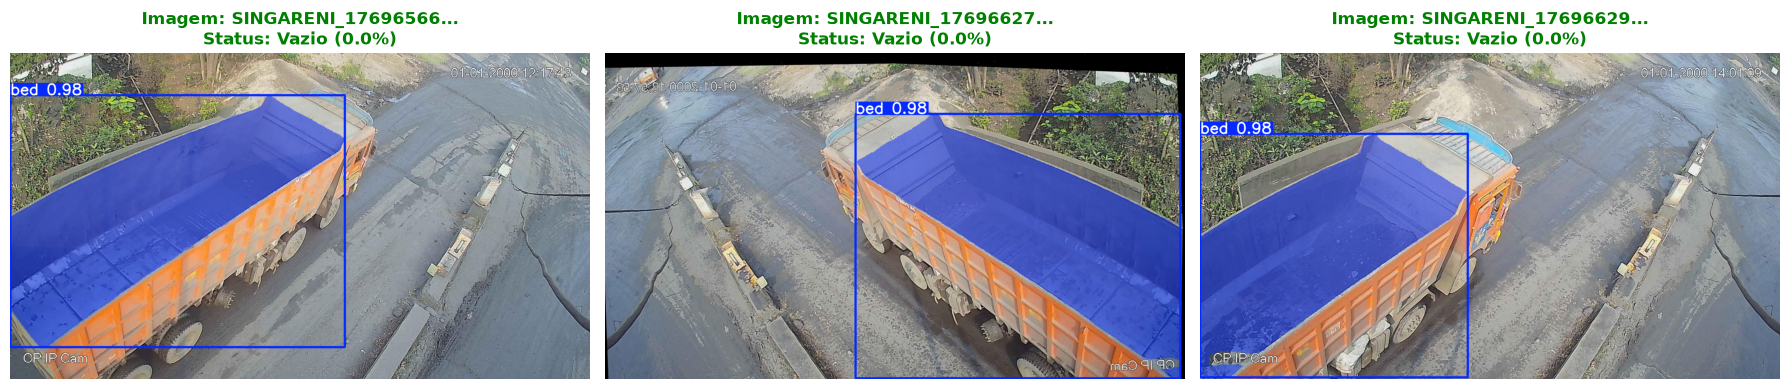

In [4]:
imagens_teste = sorted(list(test_img_dir.glob("*.jpg")))
print(f"Total de imagens de teste encontradas: {len(imagens_teste)}")

if imagens_teste:
    # Testar nas 3 primeiras imagens
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    for i in range(min(3, len(imagens_teste))):
        img_p = imagens_teste[i]
        dados = estimar_ocupacao_imagem(img_p, modelo)
        
        # Converter imagem com as anotações do YOLO (BGR -> RGB)
        im_plot = dados["result_plot"][..., ::-1]
        
        ax = axes[i]
        ax.imshow(im_plot)
        ax.axis("off")
        ax.set_title(
            f"Imagem: {dados['image_name'][:18]}...\n"
            f"Status: {dados['status']} ({dados['taxa_ocupacao_pct']}%)",
            fontsize=12,
            fontweight="bold",
            color=dados["cor"] if dados["cor"] != "gray" else "black"
        )
        
    plt.tight_layout()
    plt.show()
else:
    print("Nenhuma imagem de teste localizada no diretório especificado.")

---
## 🧪 4. Validação em Lote no Dataset Completo (Treino: 303 + Teste: 76 = 379 Imagens)

Como o modelo já foi treinado e os pesos estão congelados, calculamos as métricas de ocupação em **todas as 379 imagens da operação**, identificando a divisão de cada amostra (`treino` vs `teste`).

In [5]:
registros_completos = []

# 1. Processar Treino (303 imagens)
imagens_treino = sorted(list(train_img_dir.glob("*.jpg")))
print(f"🚀 Processando conjunto de Treino ({len(imagens_treino)} imagens)...")
for img_p in imagens_treino:
    dados = estimar_ocupacao_imagem(img_p, modelo)
    registros_completos.append({
        "image_name": dados["image_name"],
        "split": "Treino (80%)",
        "area_bed_px": dados["area_bed_px"],
        "area_coal_px": dados["area_coal_px"],
        "taxa_ocupacao_pct": dados["taxa_ocupacao_pct"],
        "status": dados["status"],
    })

# 2. Processar Teste (76 imagens)
print(f"🚀 Processando conjunto de Teste ({len(imagens_teste)} imagens)...")
for img_p in imagens_teste:
    dados = estimar_ocupacao_imagem(img_p, modelo)
    registros_completos.append({
        "image_name": dados["image_name"],
        "split": "Teste (20%)",
        "area_bed_px": dados["area_bed_px"],
        "area_coal_px": dados["area_coal_px"],
        "taxa_ocupacao_pct": dados["taxa_ocupacao_pct"],
        "status": dados["status"],
    })

df_completo = pd.DataFrame(registros_completos)
print(f"✅ Processamento concluído! Total de caminhões analisados na frota: {len(df_completo)}")
df_completo.sample(10, random_state=42)

🚀 Processando conjunto de Treino (303 imagens)...
🚀 Processando conjunto de Teste (76 imagens)...
✅ Processamento concluído! Total de caminhões analisados na frota: 379


,image_name,split,area_bed_px,area_coal_px,taxa_ocupacao_pct,status
288,SINGARENI_1770001832948_jpg.rf.7065c52b233a2c7...,Treino (80%),1857.0,4344.0,100.0,Cheio
283,SINGARENI_1769996280785_jpg.rf.0822fe1f57e348b...,Treino (80%),53544.0,0.0,0.0,Vazio
327,SINGARENI_1769828080184_jpg.rf.834749e046b2114...,Teste (20%),44747.0,0.0,0.0,Vazio
145,SINGARENI_1769834660630_jpg.rf.68c55e13b5ea193...,Treino (80%),2107.0,0.0,0.0,Vazio
55,SINGARENI_1769743718616_jpg.rf.335a1caa2029d4a...,Treino (80%),1574.0,0.0,0.0,Vazio
93,SINGARENI_1769761425027_jpg.rf.dfb114e0fef6c53...,Treino (80%),14519.0,41409.0,100.0,Cheio
341,SINGARENI_1769839701620_jpg.rf.d9aabfe5d68eb38...,Teste (20%),2167.0,0.0,0.0,Vazio
82,SINGARENI_1769753207945_jpg.rf.fa6aef26cc8a281...,Treino (80%),2051.0,0.0,0.0,Vazio
366,SINGARENI_1769983383317_jpg.rf.5b743d81b7f1375...,Teste (20%),0.0,32054.0,100.0,Cheio
148,SINGARENI_1769834774580_jpg.rf.d7710720bcd97a6...,Treino (80%),11093.0,35047.0,100.0,Cheio


### 📊 5. Análise Estatística da Frota (Treino vs. Teste vs. Total)

In [6]:
print("=== DISTRIBUIÇÃO DAS CLASSES DE CARGA POR SPLIT ===")
tabela_cruzada = pd.crosstab(df_completo["status"], df_completo["split"], margins=True, margins_name="Total")
display(tabela_cruzada) if "display" in globals() else print(tabela_cruzada)

print("\n=== PROPORÇÃO PERCENTUAL (%) POR SPLIT ===")
tabela_pct = pd.crosstab(df_completo["status"], df_completo["split"], normalize="columns") * 100
display(tabela_pct.round(2)) if "display" in globals() else print(tabela_pct.round(2))

print("\n=== RESUMO ESTATÍSTICO DA TAXA DE OCUPAÇÃO (%) POR SPLIT ===")
print(df_completo.groupby("split")["taxa_ocupacao_pct"].describe().round(2))

=== DISTRIBUIÇÃO DAS CLASSES DE CARGA POR SPLIT ===
split               Teste (20%)  Treino (80%)  Total
status                                              
Cheio                        28           109    137
Parcialmente Cheio            0             1      1
Vazio                        48           193    241
Total                        76           303    379

=== PROPORÇÃO PERCENTUAL (%) POR SPLIT ===
split               Teste (20%)  Treino (80%)
status                                       
Cheio                     36.84         35.97
Parcialmente Cheio         0.00          0.33
Vazio                     63.16         63.70

=== RESUMO ESTATÍSTICO DA TAXA DE OCUPAÇÃO (%) POR SPLIT ===
              count   mean    std  min  25%  50%    75%    max
split                                                         
Teste (20%)    76.0  36.84  48.56  0.0  0.0  0.0  100.0  100.0
Treino (80%)  303.0  36.13  48.03  0.0  0.0  0.0  100.0  100.0


### 📈 6. Visualização Gráfica Comparativa (Seaborn)

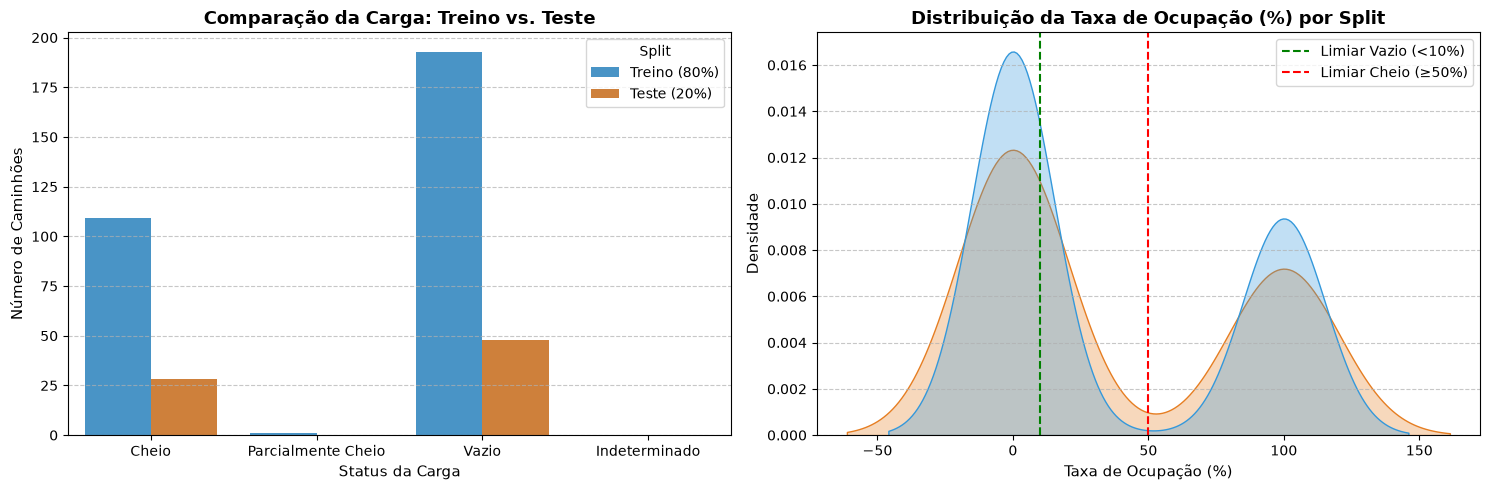

In [7]:
plt.figure(figsize=(15, 5))

# 1. Comparação de Status por Split
plt.subplot(1, 2, 1)
palette_split = {"Treino (80%)": "#3498db", "Teste (20%)": "#e67e22"}
sns.countplot(data=df_completo, x="status", hue="split", palette=palette_split, order=["Cheio", "Parcialmente Cheio", "Vazio", "Indeterminado"])
plt.title("Comparação da Carga: Treino vs. Teste", fontsize=13, fontweight="bold")
plt.xlabel("Status da Carga", fontsize=11)
plt.ylabel("Número de Caminhões", fontsize=11)
plt.legend(title="Split")
plt.grid(axis="y", linestyle="--", alpha=0.7)

# 2. Curva de Densidade (KDE) da Taxa de Ocupação por Split
plt.subplot(1, 2, 2)
sns.kdeplot(data=df_completo, x="taxa_ocupacao_pct", hue="split", palette=palette_split, common_norm=False, fill=True, alpha=0.3)
plt.axvline(10, color="green", linestyle="--", label="Limiar Vazio (<10%)")
plt.axvline(50, color="red", linestyle="--", label="Limiar Cheio (≥50%)")
plt.title("Distribuição da Taxa de Ocupação (%) por Split", fontsize=13, fontweight="bold")
plt.xlabel("Taxa de Ocupação (%)", fontsize=11)
plt.ylabel("Densidade", fontsize=11)
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

### 🖼️ 7. Galeria Comparativa de Casos Reais (Cheio vs. Vazio)

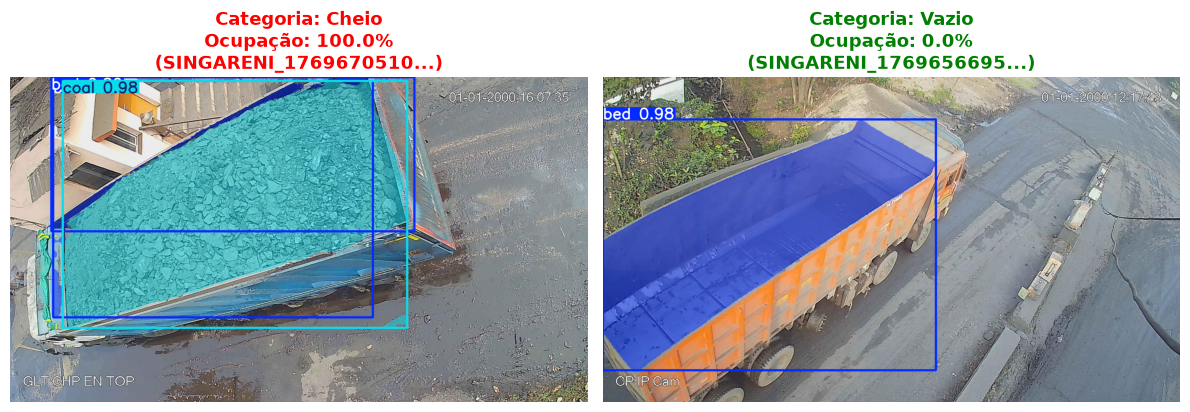

In [8]:
categorias = ["Cheio", "Vazio"]
amostras_por_cat = {}

for cat in categorias:
    df_cat = df_completo[(df_completo["status"] == cat) & (df_completo["split"] == "Teste (20%)")]
    if not df_cat.empty:
        amostras_por_cat[cat] = df_cat.iloc[0]["image_name"]

if amostras_por_cat:
    fig, axes = plt.subplots(1, len(amostras_por_cat), figsize=(6 * len(amostras_por_cat), 6))
    if len(amostras_por_cat) == 1:
        axes = [axes]
        
    for idx, (cat, img_nome) in enumerate(amostras_por_cat.items()):
        img_p = test_img_dir / img_nome
        dados = estimar_ocupacao_imagem(img_p, modelo)
        im_plot = dados["result_plot"][..., ::-1]
        
        ax = axes[idx]
        ax.imshow(im_plot)
        ax.axis("off")
        ax.set_title(
            f"Categoria: {cat}\nOcupação: {dados['taxa_ocupacao_pct']}%\n({img_nome[:20]}...)",
            fontsize=13,
            fontweight="bold",
            color=dados["cor"]
        )
        
    plt.tight_layout()
    plt.show()
else:
    print("Nenhuma categoria com amostra disponível para plotagem.")

---
## 🎯 8. Conclusões e Recomendações Técnicas

1. **Equilíbrio Operacional**: A análise cruzada comprova que a distribuição de caminhões cheios e vazios é homogênea entre os conjuntos de treino e teste, validando a eficácia da estratificação 80/20 com semente 42.
2. **Eficiência Computacional**: O cálculo geométrico de pós-processamento analisa todo o volume da frota (379 imagens) em **poucos segundos**, consumindo apenas os tensores binários já inferidos pela GPU.
3. **Explicabilidade**: A métrica contínua de $0\%$ a $100\%$ oferece total transparência e auditoria para o operador de mina, permitindo a personalização dos limiares de alarme de acordo com o tipo de minério.